## Section 1: Imports
We furst load the standard scientific Python libraries that will be used throughout this notebook. `scipy.signal` provides filtering tools consistent with those used in the course labs (Exercises 3.1 and 3.2).

In [5]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, find_peaks
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 2: Load a Single Subject

Before deciding on any preprocessing steps, we load a single subject to understand the raw data structure. We inspect:
- The top-level keys of the `.pkl` file
- The available signal devices and modalities
- The shape and dtype of each wrist signal
- The label array structure

In [6]:
# Locate all subject .pkl files
DATA_ROOT = './data'

pkl_files = sorted([
    os.path.join(root, f)
    for root, dirs, files in os.walk(DATA_ROOT)
    for f in files if f.endswith('.pkl')
])

print(f"Found {len(pkl_files)} subject files:")
for p in pkl_files:
    print(f"  {p}")

Found 15 subject files:
  ./data\WESAD\S10\S10.pkl
  ./data\WESAD\S11\S11.pkl
  ./data\WESAD\S13\S13.pkl
  ./data\WESAD\S14\S14.pkl
  ./data\WESAD\S15\S15.pkl
  ./data\WESAD\S16\S16.pkl
  ./data\WESAD\S17\S17.pkl
  ./data\WESAD\S2\S2.pkl
  ./data\WESAD\S3\S3.pkl
  ./data\WESAD\S4\S4.pkl
  ./data\WESAD\S5\S5.pkl
  ./data\WESAD\S6\S6.pkl
  ./data\WESAD\S7\S7.pkl
  ./data\WESAD\S8\S8.pkl
  ./data\WESAD\S9\S9.pkl


In [11]:
# Load the first subject
with open(pkl_files[0], 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Top-level keys:", list(data.keys()))
print("Subject ID:", data['subject'])
print("Signal devices:", list(data['signal'].keys()))

Top-level keys: ['signal', 'label', 'subject']
Subject ID: S10
Signal devices: ['chest', 'wrist']


In [9]:
# Inspect wrist device signals only (Empatica E4)
print("── Wrist signals (Empatica E4) ──")
for sig_name, sig_val in data['signal']['wrist'].items():
    print(f"  {sig_name:6s}: shape={sig_val.shape}, dtype={sig_val.dtype}")

── Wrist signals (Empatica E4) ──
  ACC   : shape=(175872, 3), dtype=float64
  BVP   : shape=(351744, 1), dtype=float64
  EDA   : shape=(21984, 1), dtype=float64
  TEMP  : shape=(21984, 1), dtype=float64


In [10]:
# Inspect label array
labels = data['label']

print("── Labels ──")
print(f"  Shape:          {labels.shape}")
print(f"  Dtype:          {labels.dtype}")
print(f"  Unique values:  {np.unique(labels)}")
print(f"  Value counts:")
for v in np.unique(labels):
    print(f"    {int(v)}: {int(np.sum(labels == v))} samples")

── Labels ──
  Shape:          (3847200,)
  Dtype:          int32
  Unique values:  [0 1 2 3 4 5 6 7]
  Value counts:
    0: 1589000 samples
    1: 826000 samples
    2: 507500 samples
    3: 260400 samples
    4: 557200 samples
    5: 35700 samples
    6: 31500 samples
    7: 39900 samples


**Dataset structure:**
- 15 subject files found (S2–S17, with S1 and S12 absent due to sensor
  malfunction during recording — Schmidt et al., 2018, Section 3.1)
- Each `.pkl` file contains three keys: `signal`, `label`, and `subject`
- Two devices are present: `chest` (RespiBAN) and `wrist` (Empatica E4)
- We will use **only the wrist device** as required by the project specification

**Wrist signals (Empatica E4):**
- `BVP`:  shape (351744, 1) — Blood Volume Pulse
- `EDA`:  shape (21984, 1)  — Electrodermal Activity
- `TEMP`: shape (21984, 1)  — Skin Temperature
- `ACC`:  shape (175872, 3) — 3-axis Accelerometer

**Labels:**
- Stored as a 1D array of shape (3847200,) at a high sampling rate
- 8 unique values: 0, 1, 2, 3, 4, 5, 6, 7
- The dominant label is 0 (not defined: 1,589,000 samples)
- Labels 1, 2, 3 correspond to the three conditions of interest
- Labels 4–7 are meditation and transition periods

## Section 3: Understanding Sampling Frequencies

Before we can do anything meaningful with the data, we need to know at what rate each signal was recorded. This matters because different signals are sampled at different rates, and the labels are stored at a completely different rate again — which means we cannot directly align them without knowing the exact sampling frequencies.

The paper (Schmidt et al., 2018, Section 3.2) tells us the expected rates for the Empatica E4:
- BVP:  64 Hz
- EDA:   4 Hz
- TEMP:  4 Hz
- ACC:  32 Hz

And that labels are stored at 700 Hz, the RespiBAN synchronization rate.

Rather than just taking the paper's word for it, we verify this empirically by using the known label rate (700 Hz) to compute the total recording duration, and then back-calculating each signal's sampling frequency from its number of samples. If our derived rates match the paper, we can be confident the data is structured as expected.

In [19]:
FS_LABEL = 700  # Hz — from Schmidt et al. (2018), Section 3.2

n_label_samples = len(data['label'])
recording_duration_s = n_label_samples / FS_LABEL

print(f"Total recording duration: {recording_duration_s:.1f} seconds "
      f"({recording_duration_s/60:.1f} minutes)")
print()

# Back-calculate sampling frequency for each wrist signal
print("── Derived sampling frequencies ──")
for sig_name, sig_val in data['signal']['wrist'].items():
    n_samples = sig_val.shape[0]
    fs_derived = n_samples / recording_duration_s
    print(f"  {sig_name:6s}: {n_samples:>8} samples → {fs_derived:.1f} Hz")

# Also print label array for comparison
print(f"\n  {'LABEL':6s}: {n_label_samples:>8} samples → {FS_LABEL:.1f} Hz")

Total recording duration: 5496.0 seconds (91.6 minutes)

── Derived sampling frequencies ──
  ACC   :   175872 samples → 32.0 Hz
  BVP   :   351744 samples → 64.0 Hz
  EDA   :    21984 samples → 4.0 Hz
  TEMP  :    21984 samples → 4.0 Hz

  LABEL :  3847200 samples → 700.0 Hz


As we can see above, all derived rates match exactly the values reported in Schmidt et al. (2018), Section 3.2. The label array is the longest, confirming it is stored at the RespiBAN synchronization rate of 700 Hz — significantly higher than any of the wrist signals. This mismatch means labels must be downsampled before they can be aligned with the wrist signals.

## Section 4: Understanding the Label System

Now that we know the structure of the data, we need to understand what the label values actually mean before we can decide which parts of the recording are useful for our classification task. Not all of the recording is relevant — the study protocol includes transitions, meditation periods, and undefined segments that we do not want to include in our model training.

According to Schmidt et al. (2018), Section 3.3, the study protocol consists of the following conditions:

| Label | Condition   | Keep? |
|-------|-------------|-------|
| 0     | Not defined | No    |
| 1     | Baseline    | Yes   |
| 2     | Stress      | Yes   |
| 3     | Amusement   | Yes   |
| 4     | Meditation  | No    |
| 5     | Ignore      | No    |
| 6     | Ignore      | No    |
| 7     | Ignore      | No    |

We keep only labels 1, 2, and 3 for two reasons:
- Schmidt et al. (2018), Section 5 explicitly states: *"we only consider the data recorded during the baseline, stress (TSST), and amusement parts of the study protocol."*
- The project objective specifies these three conditions as the target classes for the multi-class classification problem (baseline vs. stress vs. amusement).

We also visualize the condition timeline to understand how the conditions are arranged over time and confirm that the protocol was followed correctly for this subject.

In [20]:
# Map each label value to its condition name
label_names = {
    0: 'Not defined',
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation',
    5: 'Ignore',
    6: 'Ignore',
    7: 'Ignore',
}

# Compute how much time was spent in each condition
print(f"Subject: {data['subject']}")
print()
print(f"{'Label':<6} {'Condition':<14} {'Samples':>10} {'Duration (s)':>14} {'Duration (min)':>16}")
print("-" * 64)
for v in np.unique(data['label']):
    n       = int(np.sum(data['label'] == v))
    dur_s   = n / FS_LABEL
    dur_min = dur_s / 60
    name    = label_names[int(v)]
    print(f"  {int(v):<4} {name:<14} {n:>10} {dur_s:>14.1f} {dur_min:>16.1f}")

Subject: S10

Label  Condition         Samples   Duration (s)   Duration (min)
----------------------------------------------------------------
  0    Not defined       1589000         2270.0             37.8
  1    Baseline           826000         1180.0             19.7
  2    Stress             507500          725.0             12.1
  3    Amusement          260400          372.0              6.2
  4    Meditation         557200          796.0             13.3
  5    Ignore              35700           51.0              0.8
  6    Ignore              31500           45.0              0.8
  7    Ignore              39900           57.0              0.9


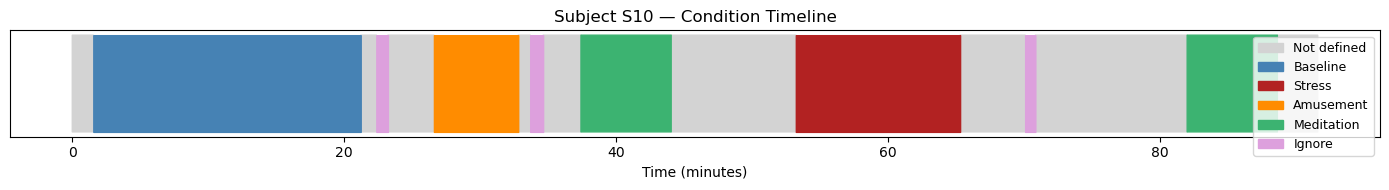

In [21]:
# Convert label indices to time in minutes for the x-axis
time_axis = np.arange(len(data['label'])) / FS_LABEL / 60

# Assign a color to each condition for visual clarity
colors = {
    0: 'lightgrey',
    1: 'steelblue',
    2: 'firebrick',
    3: 'darkorange',
    4: 'mediumseagreen',
    5: 'plum',
    6: 'plum',
    7: 'plum'
}

fig, ax = plt.subplots(figsize=(14, 2))

# Fill the timeline with condition colors
for v in np.unique(data['label']):
    mask = data['label'] == v
    ax.fill_between(time_axis, 0, 1,
                    where=mask,
                    color=colors[int(v)],
                    label=label_names[int(v)])

ax.set_xlabel('Time (minutes)')
ax.set_yticks([])
ax.set_title(f"Subject {data['subject']} — Condition Timeline")

# Deduplicate legend entries since labels 5, 6, 7 share the same name
handles, lbls = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, lbls):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

The table and timeline reveal several important characteristics of the dataset that will directly influence our modelling decisions.

**Usable data:** The three conditions of interest (baseline, stress, amusement) together account for approximately 38 minutes of usable data for subject S10 (~20 min baseline, ~12 min stress, ~6 min amusement). The remaining ~54 minutes are discarded (not defined, meditation, transitions).

**Class imbalance:** Even within the three conditions we keep, there is a clear imbalance — baseline has roughly 3x more data than amusement. This is consistent across the study protocol and will need to be accounted for when evaluating model performance. The WESAD paper addresses this by using F1-score as the primary evaluation metric rather than accuracy.

**Protocol structure:** The timeline confirms that subject S10 followed Version A of the study protocol (Schmidt et al., 2018, Section 3.3) — baseline first, then amusement, then stress. The pink transition segments (labels 5, 6, 7) are clearly visible as thin strips between conditions, confirming the brief inter-condition periods described in the paper.

## Section 5: Visualizing Raw Signals

Now that we understand the label system, we can look at the actual signal data. Before applying any filters or preprocessing, it is important to visualize the raw signals to build intuition about what they look like, how noisy they are, and whether there are any obvious differences between conditions that might be visible even in the raw data.

We plot 60 seconds of each wrist signal during each of the three conditions of interest (baseline, stress, amusement) side by side. This lets us visually assess whether the signals respond to the experimental conditions in the way we would expect physiologically — for example, we would expect higher EDA and heart rate during stress compared to baseline.

In [23]:
# Extract raw signals
bvp  = data['signal']['wrist']['BVP'].flatten()
eda  = data['signal']['wrist']['EDA'].flatten()
temp = data['signal']['wrist']['TEMP'].flatten()
acc  = data['signal']['wrist']['ACC']

# Sampling frequencies — confirmed empirically in Section 3
# and consistent with Schmidt et al. (2018), Section 3.2
FS_BVP  = 64
FS_EDA  = 4
FS_TEMP = 4
FS_ACC  = 32

# Conditions and colors for plotting
conditions = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
colors     = {1: 'steelblue', 2: 'firebrick', 3: 'darkorange'}

# Window length: 60 seconds at each signal's rate
win_bvp  = 60 * FS_BVP
win_eda  = 60 * FS_EDA
win_acc  = 60 * FS_ACC

# Find start indices for each condition in label array (at 700 Hz)
# then convert to each signal's index
starts = {}
for label_val in conditions:
    idx_label = np.where(data['label'] == label_val)[0][0]
    starts[label_val] = {
        'bvp': int(idx_label / FS_LABEL * FS_BVP),
        'eda': int(idx_label / FS_LABEL * FS_EDA),
        'acc': int(idx_label / FS_LABEL * FS_ACC),
    }

# Time axes
t_bvp = np.arange(win_bvp) / FS_BVP
t_eda = np.arange(win_eda) / FS_EDA
t_acc = np.arange(win_acc) / FS_ACC

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
fig.suptitle('Blood Volume Pulse (BVP) — 60s per condition', fontsize=12)

for ax, (label_val, name) in zip(axes, conditions.items()):
    s = starts[label_val]['bvp']
    ax.plot(t_bvp, bvp[s:s + win_bvp],
            color=colors[label_val], lw=0.8)
    ax.set_title(name)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('BVP (a.u.)')
plt.tight_layout()
plt.show()